<h1 style="text-align: center"> mlpro-classification-bank-churn-2025 </h1>

## Import des libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Chargement des données

In [2]:
train_data = pd.read_csv('data/train_data.csv')
test_data = pd.read_csv('data/test_data.csv')


train_data

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
143574,97639,15759915,Onwumelu,559,Germany,Male,45.0,3,111634.29,1,1.0,1.0,103349.74,0
143575,95939,15769974,Shih,597,Germany,Male,41.0,10,119182.73,1,0.0,0.0,121299.14,0
143576,152315,15592028,Hsiao,576,Spain,Male,31.0,6,127299.56,1,1.0,1.0,57569.89,0
143577,117952,15804009,Ch'ang,751,France,Female,27.0,4,90721.11,1,0.0,0.0,84496.78,0


In [3]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 143579 entries, 0 to 143578
Data columns (total 14 columns):
 #   Column           Non-Null Count   Dtype  
---  ------           --------------   -----  
 0   ID               143579 non-null  int64  
 1   CustomerId       143579 non-null  int64  
 2   Surname          143579 non-null  object 
 3   CreditScore      143579 non-null  int64  
 4   Geography        143579 non-null  object 
 5   Gender           143579 non-null  object 
 6   Age              143579 non-null  float64
 7   Tenure           143579 non-null  int64  
 8   Balance          143579 non-null  float64
 9   NumOfProducts    143579 non-null  int64  
 10  HasCrCard        143579 non-null  float64
 11  IsActiveMember   143579 non-null  float64
 12  EstimatedSalary  143579 non-null  float64
 13  Exited           143579 non-null  int64  
dtypes: float64(5), int64(6), object(3)
memory usage: 15.3+ MB


In [4]:
train_data.nunique()

ID                 143579
CustomerId          22017
Surname              2765
CreditScore           456
Geography               3
Gender                  2
Age                    71
Tenure                 11
Balance             27258
NumOfProducts           4
HasCrCard               2
IsActiveMember          2
EstimatedSalary     50076
Exited                  2
dtype: int64

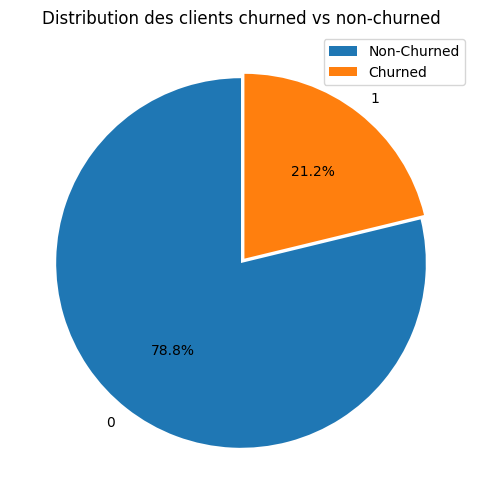

In [5]:
train_data['Exited'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=(0, 0.03),
    figsize=(10,6)
)
plt.title('Distribution des clients churned vs non-churned')
plt.ylabel('')
plt.legend(['Non-Churned', 'Churned'])
plt.show()

- Nous avons **78.8%** des clients qui n'ont pas résilié leur contrat contre **21.2%** qui ont résilié leur contrat, soit une différence de **57.6%**.

## Analyse Univarié

### 1. Variable discrète

Nous avons 7 variables discrètes: 
- Geography
- Gender
- Tenure
- NumOfProducts
- HasCrCard
- IsActiveMember
- Exited

#### 1.1 Geography

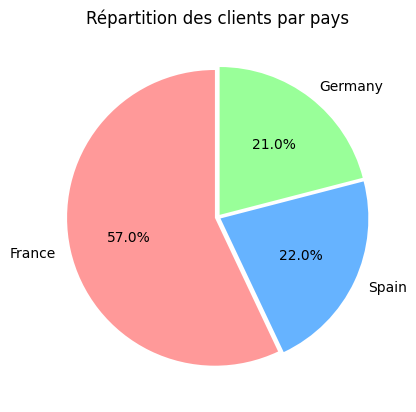

In [6]:
train_data['Geography'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.02, 0.02, 0.02),
    colors=['#ff9999','#66b3ff','#99ff99']
)
plt.title('Répartition des clients par pays')
plt.ylabel('')
plt.show()

- **57%** des clients résident en France,

- **22%** résident en Espagne et

- **21%** résident en  Allemagne

#### 1.2 Gender

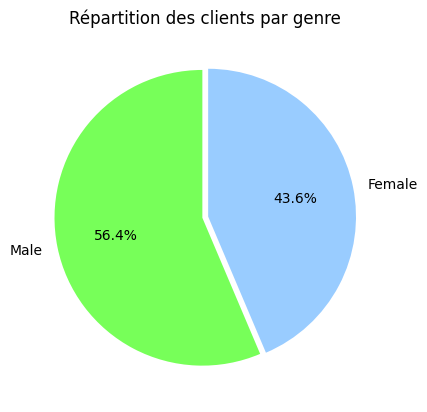

In [7]:
train_data['Gender'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    explode=(0.02, 0.02),
    colors=['#77ff59','#99ccff']
)
plt.title('Répartition des clients par genre')
plt.ylabel('')
plt.show()

- **56.4%** des clients sont des **hommes** contre **43.6%** de **femmes**.

#### 1.3 Tenure

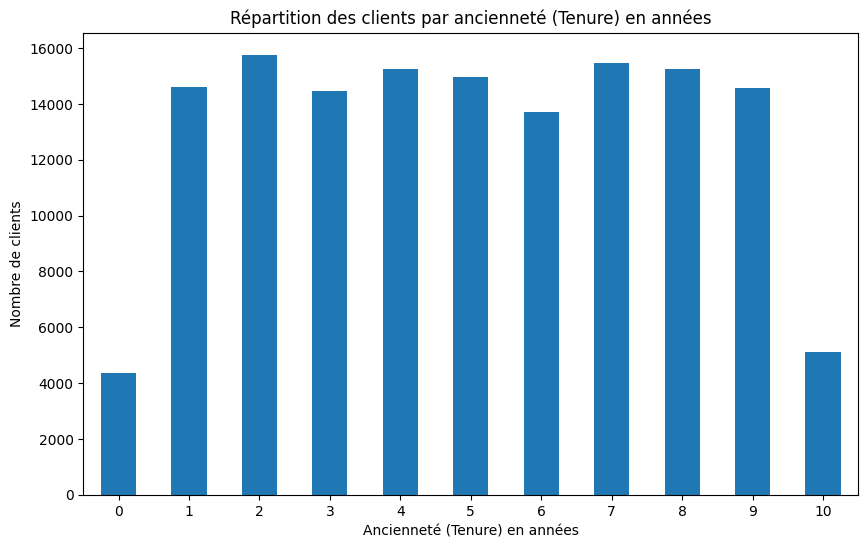

In [40]:
train_data['Tenure'].value_counts().sort_index().plot(
    kind='bar',
    figsize=(10,6),
    rot=0
)
plt.title('Répartition des clients par ancienneté (Tenure) en années')
plt.xlabel('Ancienneté (Tenure) en années')
plt.ylabel('Nombre de clients')
plt.show()

#### 1.4 NumOfProducts

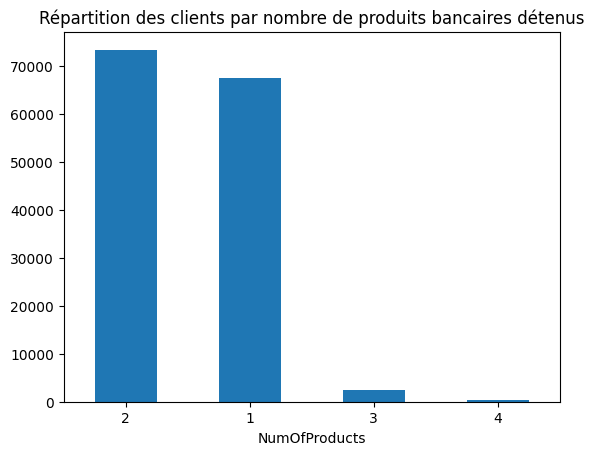

In [44]:
train_data['NumOfProducts'].value_counts().plot(
    kind='bar',
    rot=0,
)
plt.title('Répartition des clients par nombre de produits bancaires détenus')
plt.ylabel('')
plt.show()

- La majorité des clients utilisent entre 1 à 2 produits(services) de la banque